In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
import math

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

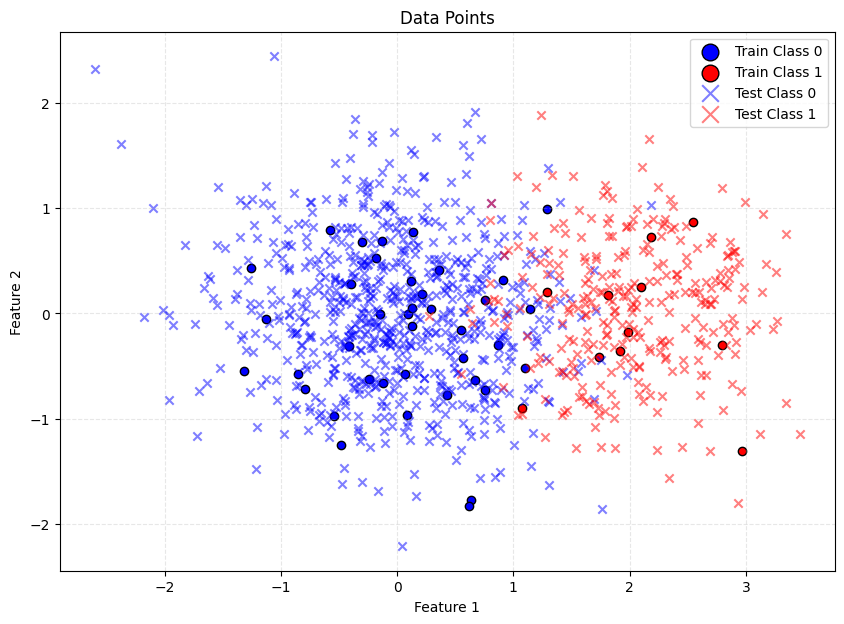

In [3]:
def indicator_func(U, p):
    if U < p:
        return 1
    return 0

U = np.random.rand() #uniform distribution
# bernoulli distribution
B = indicator_func(U, 0.3)

def bernoulli(p):
    U = np.random.rand()
    return indicator_func(U, p)

N_train = 50
N_test = 10**3

y_train = np.array([bernoulli(0.3) for i in range(N_train)])
y_test = np.array([bernoulli(0.3) for i in range(N_test)])

mu_0 = [0, 0]
mu_1 = [2, 0]
sigma_0 = [[0.5, 0], [0, 0.5]]
sigma_1 = [[0.4, 0], [0, 0.4]]

x_train = np.array([np.random.multivariate_normal(mu_0, sigma_0) if y_train[i] == 0 else np.random.multivariate_normal(mu_1, sigma_1) for i in range(N_train)])
x_test = np.array([np.random.multivariate_normal(mu_0, sigma_0) if y_test[i] == 0 else np.random.multivariate_normal(mu_1, sigma_1) for i in range(N_test)])

plt.figure(figsize=(10, 7))


plt.scatter(x_train[y_train == 0, 0], x_train[y_train == 0, 1], 
            c='blue', marker='o', label='Train Class 0', alpha=1, edgecolors='k')
plt.scatter(x_train[y_train == 1, 0], x_train[y_train == 1, 1], 
            c='red', marker='o', label='Train Class 1', alpha=1, edgecolors='k')
plt.scatter(x_test[y_test == 0, 0], x_test[y_test == 0, 1], 
            c='blue', marker='x', label='Test Class 0', alpha=0.5)
plt.scatter(x_test[y_test == 1, 0], x_test[y_test == 1, 1], 
            c='red', marker='x', label='Test Class 1', alpha=0.5)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Points')
plt.legend(loc='upper right', markerscale=2) # markerscale makes the legend symbols larger
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

## **Answer**

The optimal decision rule, $f(x)$, assigns x to class 1 if $Prob(Y=1∣x)>Prob(Y=0∣x)$, and to class 0 otherwise.

Using what we have seen in the CM, the decision rule simplifies to a comparaison:

Classify as 1 if: $p(x∣Y=1)⋅p>p(x∣Y=0)⋅(1−p)$ with $p(x∣Y=k)$ is the pdf and $p$ is that of Bernoulli Distribution

Dividing both sides, we get the classifier in terms of the likelihood ratio:

##### The Boundary Region

The boundary region is defined by the set of points x where the posterior probabilities are equal: $Prob(Y=1∣x)=Prob(Y=0∣x)$

which comes down to $p(x∣Y=1)⋅p=p(x∣Y=0)⋅(1−p)$

The covariance matrices are diagonal, which simplifies the math:

$p(x∣Y=1)=\frac{1}{ \pi}​exp(−∥x−μ_0​∥^2)$

$p(x∣Y=1)=\frac{1}{ 0.8 \pi}​exp(−1.25∥x−μ​_1∥^2)$

Finally, this is the form of the boundary region: $$1.25∥x−μ_1​∥^2−1.0∥x−μ_0​∥^2=ln(\frac{p}{0.8(1-p)}​)$$

This confirms that the boundary is quadratic (a circle, ellipse, or hyperbola).

**Note**: We wrote $Prob(Y=k∣x)$ instead of $Prob(Y=0∣X \in B_\epsilon (x_0))$. We are aware that it's a continuous random variable but we did it for the sake of simplifying the notation like most books as mentionned in the slides

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [4]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal

class BayesClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self, epsilon, p):
        self.epsilon = epsilon
        self.p = p
    
    def fit(self, X, y):
        self.mu_0 = np.array([0, 0])
        self.mu_1 = np.array([self.epsilon, 0])

        self.sigma_0 = np.array([[0.5, 0],
                                  [0, 0.5]])
        self.sigma_1 = np.array([[0.4, 0],
                                  [0, 0.4]])
        
        return self
    
    def predict(self, X):
        prob_0 = (1 - self.p) * multivariate_normal.pdf(X, self.mu_0, self.sigma_0)
        prob_1 = self.p * multivariate_normal.pdf_test_test(X, self.mu_1, self.sigma_1)
        return (prob_1 > prob_0).astype(int)
    

def estimate_error(epsilon, p):
    N = 10**4
    mu_one = np.array([epsilon, 0])
    y_test = np.array([bernoulli(0.3) for i in range(N)])
    x_test = np.array([np.random.multivariate_normal(mu_0, sigma_0) if y_test[i] == 0 else np.random.multivariate_normal(mu_one, sigma_1) for i in range(N)])
    
    classifier = BayesClassifier(epsilon, p).fit(None, None)
    y_pred = classifier.predict(x_test)
    return 1 - accuracy_score(y_test, y_pred)

print("Estimated error rate for epsilon=2:", estimate_error(2, 0.3))


Estimated error rate for epsilon=2: 0.05920000000000003


<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3647/4148618285.py:9: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\epsilon$')


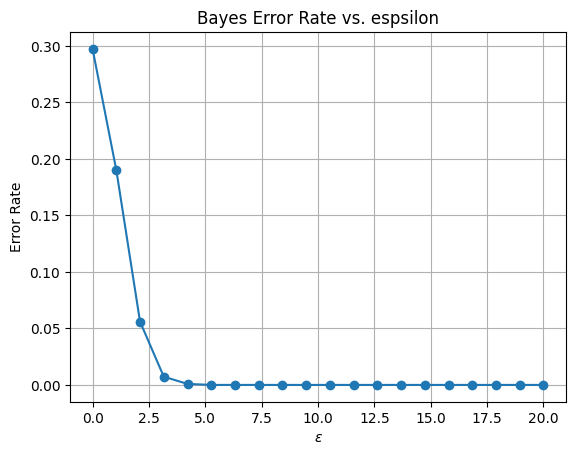

In [5]:
epsilons = np.linspace(0, 20, 20)
errors = []

for eps in epsilons:
    error_val = estimate_error(eps, 0.3)
    errors.append(error_val)

plt.plot(epsilons, errors, marker='o')
plt.xlabel('$\epsilon$')
plt.ylabel('Error Rate')
plt.title('Bayes Error Rate vs. espsilon')
plt.grid(True)
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

# **Answer**

Given that the datasets are generated from multivariate Gaussian distributions with different means and different covariance $\Sigma_1 \neq \Sigma_2$ matrices, the most adequate classifier is Quadratic Discriminant Analysis (QDA).

QDA assumes that the data for each class is drawn from a multivariate Gaussian distribution with its own mean​ and its own covariance matrix; therefore the quadratic terms do not cancel out when we set the posterior probabilities equal to each other.

LDA would have been a better choice if the covariances were equal.

We also see that the correlation is zero, so naïve Bayes could give good results because independance is equivalent to no correlation in normal ditributions.

Finally, given that the boundary is quadratic not linear, Logistic Regression isn't the most adequate classifier.



**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [7]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


LDA_model = LDA()
QDA_model = QDA()
Logistic_model = LogisticRegression()

N_train = 50
N_test = 10**3

def generate_data(n, mu0, mu1, sig0, sig1, p=0.3):
    y = (np.random.rand(n) < p).astype(int)
    x = np.zeros((n, 2))
    x[y == 0] = np.random.multivariate_normal(mu0, sig0, size=np.sum(y == 0))
    x[y == 1] = np.random.multivariate_normal(mu1, sig1, size=np.sum(y == 1))
    return x, y

x_train, y_train = generate_data(50, mu_0, mu_1, sigma_0, sigma_1)
x_test, y_test = generate_data(1000, mu_0, mu_1, sigma_0, sigma_1)

LDA_model.fit(x_train, y_train)
QDA_model.fit(x_train, y_train)
Logistic_model.fit(x_train, y_train)

y_pred_LDA = LDA_model.predict(x_test)
y_pred_QDA = QDA_model.predict(x_test)
y_pred_Logistic = Logistic_model.predict(x_test)

error_LDA = np.mean(y_pred_LDA != y_test)
error_QDA = np.mean(y_pred_QDA != y_test)
error_Logistic = np.mean(y_pred_Logistic != y_test)

print(f"LDA Error Rate: {error_LDA:.4f}")
print(f"QDA Error Rate: {error_QDA:.4f}")
print(f"Logistic Regression Error Rate: {error_Logistic:.4f}")

print(f"Bayes Classifier Error Rate: {estimate_error(2, 0.3)}")



LDA Error Rate: 0.0720
QDA Error Rate: 0.0680
Logistic Regression Error Rate: 0.0650
Bayes Classifier Error Rate: 0.06030000000000002


QDA should in theory achieve an error rate very close to the Bayes error rate.

**The effect of sample size:**

The gap between the test error and the Bayes error rate is primarily driven by estimation error. If $N_{train}$ is small then the gap will be large for all models as they struggle to learn the structure from limited data; but if it's large enough QDA's gap will shrink towards zero (approaching the Bayes error) because it is a consistent estimator for this data distribution

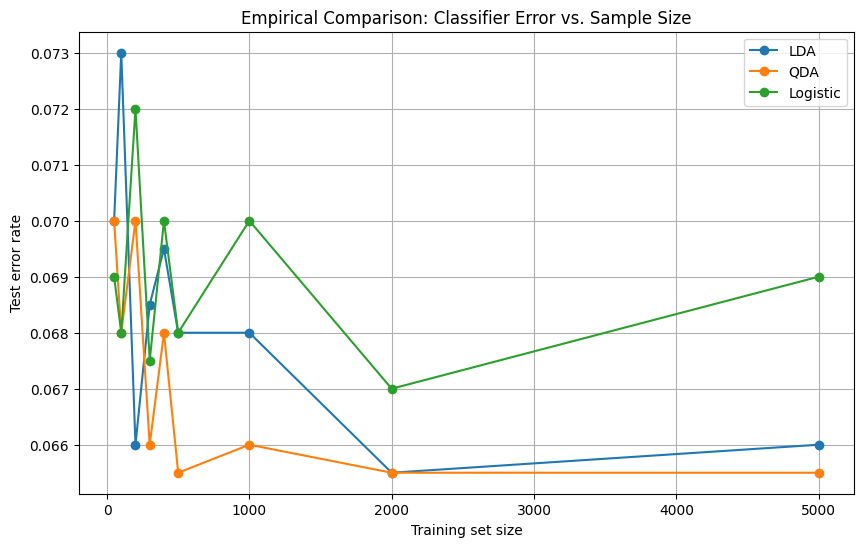

In [13]:
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


sample_sizes = [50, 100, 200,300, 400, 500, 1000, 2000, 5000]
results = {"LDA": [], "QDA": [], "Logistic": []}


x_test, y_test = generate_data(2000, mu_0, mu_1, sigma_0, sigma_1)

for n in sample_sizes:
    x_train, y_train = generate_data(n, mu_0, mu_1, sigma_0, sigma_1)
    
    models = {"LDA": LDA(), "QDA": QDA(), "Logistic": LogisticRegression()}
    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        error = 1 - accuracy_score(y_test, y_pred)
        results[name].append(error)


plt.figure(figsize=(10, 6))
for name, errors in results.items():
    plt.plot(sample_sizes, errors, marker='o', label=name)

plt.xlabel('Training set size')
plt.ylabel('Test error rate')
plt.title('Empirical Comparison: Classifier Error vs. Sample Size')
plt.legend()
plt.grid(True)
plt.show()

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score

# new test set 
N_new_test = 1000
mu_1_new = np.array([0.5, 0])

x_new_test, y_new_test = generate_data(N_new_test, mu_0, mu_1_new, sigma_0, sigma_1, p=0.7)

# evaluate the existing models trained in (e) on this new test set
models = {
    "LDA": LDA_model,
    "QDA": QDA_model,
    "Logistic Regression": Logistic_model
}

print("Results on D'_test (epsilon=0.5, p=0.7):")
for name, model in models.items():
    y_pred = model.predict(x_new_test)
    error = np.mean(y_pred != y_new_test)
    print(f"  {name} Error Rate: {error:.4f}")

# Bayes error 
print(f"  Bayes Classifier Error Rate: {estimate_error(0.5, 0.7):.4f}")

Results on D'_test (epsilon=0.5, p=0.7):
  LDA Error Rate: 0.6050
  QDA Error Rate: 0.6120
  Logistic Regression Error Rate: 0.6240
  Bayes Classifier Error Rate: 0.5412


## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [23]:
df = pd.read_csv('titanic/train.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


**ANSWER** In the dataset, we had to deal with some rows that were missing data, and with some categories that were in str. 
- PassengerId : we kept it in the database but removed it from X since it did not convey information
- Survived : we removed it from X, put it in y_train to verify the model
- Pclass : no changes
- Name : we extracted the titles, as they were a sign of someone's rank in society (a higher rank would mean a higher chance to be saved)
- Age : some data was missing. We chose to fill it with the mean of the feature "age". We also created a feature 'Is_Child' which would be equal to one when the person is older than 14.
- Sex : The data was in str, so we chose to one hot encoded it
- SibSp and Parch : kept and used to create the features "LargeFamily" and "IsAlone", since larger groups or people travelling alone could not have priority.
- Ticket : used to find people that came in group (with the same ticket), but removed from X
- Fare : used with the groups from the 'Ticket' class to find the individual fare (class 'Fare_Individual')
- Cabin : used to part the people that had a cabin and the ones who didn't ('Has_Cabin') and to create a class 'Deck' (to place the people on the boat). People without cabins are put in the deck 'U' (for unknown). Also, one person had a cabin named 'T' but we supposed it was a misinformation and, after looking at the information of the passenger, we chose to put them in deck 'A'.  
- Embarked :  The data was in str, so we chose to one hot encoded it

In [24]:
#Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

num_features = ['Age', 'Fare_Individual', 'SibSp', 'Parch', 'FamilySize']
cat_features = ['Sex', 'Embarked', 'Pclass', 'Title', 'Deck', 'Has_Cabin', 'Is_Child', 'Is_Alone', 'LargeFamily']

#gestion des données numériques manquantes+ scaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

#gestion des données str manquantes + one hot encding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [30]:
#Entrainement et verif du modele
from sklearn.model_selection import cross_val_score, StratifiedKFold
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold

#fonctions de maj de la database
def extract_titles(df):
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    return df

def family_detail(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['Is_Alone'] = 0
    df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
    
    #taille famille
    df['LargeFamily'] = (df['FamilySize'] > 4).astype(int)
    
    return df

def true_ticket(df):
    ticket_counts = df.groupby('Ticket')['Ticket'].transform('count')
    df['Fare_Individual'] = df['Fare'] / ticket_counts
    
    return df





df = pd.read_csv('titanic/train.csv')


# nettoyage des données
df = extract_titles(df)
df = family_detail(df)
df = true_ticket(df)
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df['Deck'] = df['Cabin'].str[0].fillna('U').replace('T', 'A')
df['Is_Child'] = (df['Age'] < 15).astype(int)


y = df['Survived']
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'Has_Cabin', 'Is_Child', 'Title', 'Is_Alone','FamilySize',
        'LargeFamily', 'Fare_Individual']]






In [33]:
#df test

df_test = pd.read_csv('titanic/test.csv')
df_test = extract_titles(df_test)
df_test = family_detail(df_test)
df_test = true_ticket(df_test)
df_test['Has_Cabin'] = df_test['Cabin'].notnull().astype(int)
df_test['Deck'] = df_test['Cabin'].str[0].fillna('U').replace('T', 'A')
df_test['Is_Child'] = (df_test['Age'] < 15).astype(int)
X_test = df_test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Deck', 'Has_Cabin', 'Is_Child', 'Title', 'Is_Alone', 'FamilySize',
                  'LargeFamily', 'Fare_Individual']]

# cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [34]:
#test of the model and generation of the csv

from sklearn.model_selection import GridSearchCV

#grid search to find the best parameters
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 8, 15],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=skf, scoring='accuracy')
grid_search.fit(X, y)
print(f"Meilleurs paramètres : {grid_search.best_params_}")

model_2=grid_search.best_estimator_
y_pred_2=model_2.predict(X_test)
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_2
})
submission.to_csv('soumission.csv', index=False)

Meilleurs paramètres : {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}


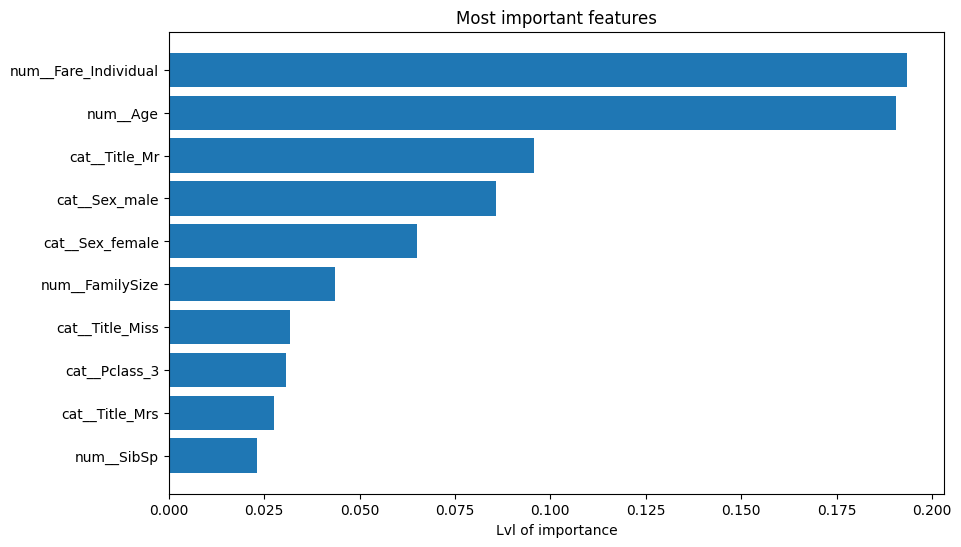

In [37]:
#info on the most important data
import pandas as pd
import matplotlib.pyplot as plt


rf_model = model_pipeline.named_steps['classifier']
feature_names = model_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10))
plt.gca().invert_yaxis()
plt.title("Most important features")
plt.xlabel("Lvl of importance")
plt.show()

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

**ANSWER** We ended up chosing a RandomForest classifier for several reasons:
- It is robust to the presence of different types of data 
- It is robust to outliers
- It can find complex combinations of rules
- By creating several trees, it reduces the risk of overfitting
- We can see which are the most important classes

Our final score on the leaderboard was 0.7751.